
---LOADING ADULT DATASET---

Dataset shape: (48842, 14)
Target distribution:
target
0    37155
1    11687
Name: count, dtype: int64

---5-FOLD CROSS-VALIDATION---


Running: Logistic Regression
Accuracy : 0.8581 +/- 0.0021
F1       : 0.6744 +/- 0.0049
ROC AUC  : 0.9135 +/- 0.0022

Running: Random Forest
Accuracy : 0.8526 +/- 0.0024
F1       : 0.6683 +/- 0.0059
ROC AUC  : 0.9013 +/- 0.0024

Running: Gradient Boosting
Accuracy : 0.8735 +/- 0.0023
F1       : 0.7120 +/- 0.0053
ROC AUC  : 0.9282 +/- 0.0018

---MODEL COMPARISON - MEAN +/- STD---

              Model  Accuracy Mean  Accuracy Std  F1 Mean   F1 Std  ROC AUC Mean  ROC AUC Std
  Gradient Boosting       0.873531      0.002345 0.711957 0.005316      0.928229     0.001787
Logistic Regression       0.858093      0.002091 0.674368 0.004916      0.913522     0.002231
      Random Forest       0.852627      0.002411 0.668313 0.005912      0.901336     0.002352

---INDIVIDUAL FOLD RESULTS---

              Model  Fold  Accuracy       F1

C:\Users\samir\AppData\Local\Temp\ipykernel_13484\1326655968.py:136: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(values, labels=list(models))


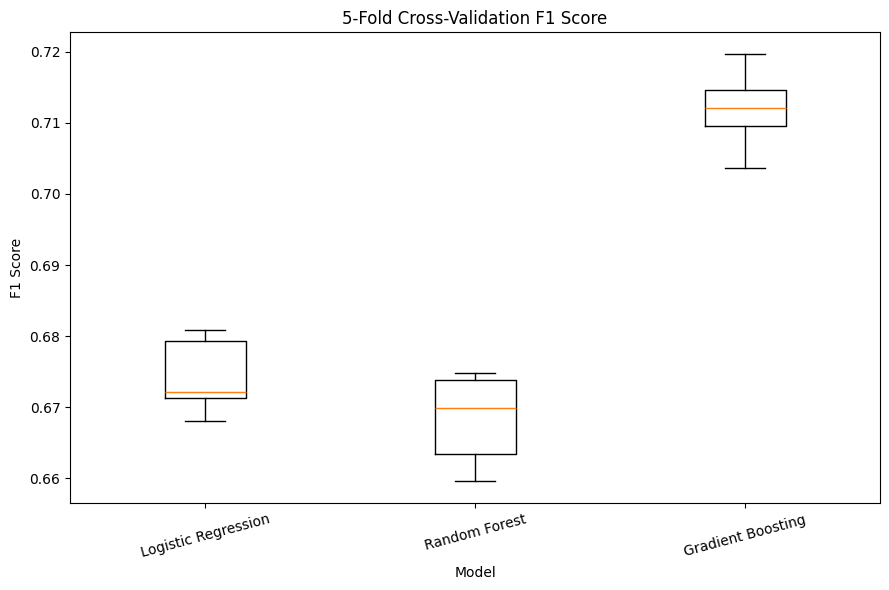

C:\Users\samir\AppData\Local\Temp\ipykernel_13484\1326655968.py:136: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(values, labels=list(models))


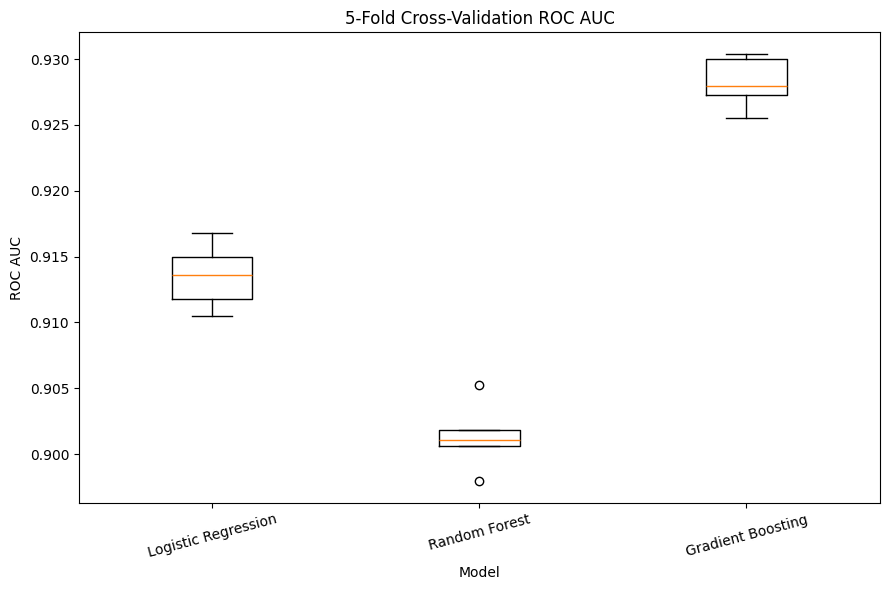

C:\Users\samir\AppData\Local\Temp\ipykernel_13484\1326655968.py:136: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(values, labels=list(models))


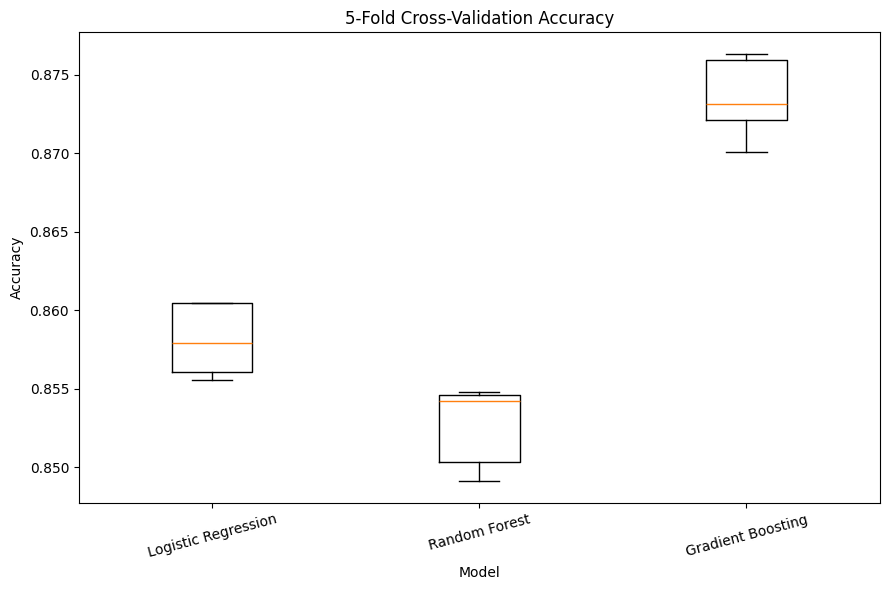


---BEST MODEL BASED ON F1---

Model: Gradient Boosting
Mean F1: 0.7120
Std F1: 0.0053
Mean ROC AUC: 0.9282
Mean Accuracy: 0.8735


In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import make_scorer, f1_score

os.makedirs("../outputs", exist_ok=True)

print("\n---LOADING ADULT DATASET---\n")
adult = fetch_openml("adult", version=2, as_frame=True)
df = adult.frame.copy().replace("?", np.nan)
df["target"] = df["class"].map({"<=50K": 0, ">50K": 1}).astype(int)
X = df.drop(columns=["class", "target"])
y = df["target"]

print("Dataset shape:", X.shape)
print("Target distribution:")
print(y.value_counts())


def create_engineered_features(data):
    data = data.copy()
    data["age_bucket"] = pd.cut(
        data["age"],
        bins=[0, 25, 35, 45, 55, 65, np.inf],
        labels=["Young", "Early_Career", "Mid_Career", "Experienced", "Senior", "Older"],
        include_lowest=True,
    )
    data["hours_bucket"] = pd.cut(
        data["hours-per-week"],
        bins=[0, 30, 40, 50, 60, np.inf],
        labels=["Part_Time", "Standard", "Overtime", "High_Hours", "Very_High_Hours"],
        include_lowest=True,
    )
    data["capital_gain_flag"] = (data["capital-gain"] > 0).astype(int)
    data["log_capital_gain"] = np.log1p(data["capital-gain"])
    data["higher_education"] = (data["education-num"] >= 13).astype(int)
    data["education_hours_interaction"] = data["education-num"] * data["hours-per-week"]
    data["capital_loss_flag"] = (data["capital-loss"] > 0).astype(int)
    data["age_hours_interaction"] = data["age"] * data["hours-per-week"]
    return data


feature_engineering = FunctionTransformer(create_engineered_features, validate=False)
numeric_features = [
    "age", "fnlwgt", "education-num", "capital-gain", "capital-loss", "hours-per-week",
    "capital_gain_flag", "log_capital_gain", "higher_education",
    "education_hours_interaction", "capital_loss_flag", "age_hours_interaction",
]
categorical_features = [
    "workclass", "education", "marital-status", "occupation", "relationship",
    "race", "sex", "native-country", "age_bucket", "hours_bucket",
]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])
preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features),
])

models = {
    "Logistic Regression": LogisticRegression(solver="liblinear", max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "Gradient Boosting": HistGradientBoostingClassifier(max_iter=100, learning_rate=0.1, random_state=42),
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {"accuracy": "accuracy", "f1": make_scorer(f1_score), "roc_auc": "roc_auc"}
all_results = []
fold_results = []

print("\n---5-FOLD CROSS-VALIDATION---\n")
for model_name, model in models.items():
    print(f"\nRunning: {model_name}")
    pipeline = Pipeline([
        ("feature_engineering", feature_engineering),
        ("preprocessor", preprocessor),
        ("classifier", model),
    ])
    scores = cross_validate(
        pipeline, X, y, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=False,
    )
    for fold_number in range(5):
        fold_results.append({
            "Model": model_name,
            "Fold": fold_number + 1,
            "Accuracy": scores["test_accuracy"][fold_number],
            "F1": scores["test_f1"][fold_number],
            "ROC_AUC": scores["test_roc_auc"][fold_number],
        })
    result = {
        "Model": model_name,
        "Accuracy Mean": scores["test_accuracy"].mean(),
        "Accuracy Std": scores["test_accuracy"].std(),
        "F1 Mean": scores["test_f1"].mean(),
        "F1 Std": scores["test_f1"].std(),
        "ROC AUC Mean": scores["test_roc_auc"].mean(),
        "ROC AUC Std": scores["test_roc_auc"].std(),
    }
    all_results.append(result)
    print(f"Accuracy : {result['Accuracy Mean']:.4f} +/- {result['Accuracy Std']:.4f}")
    print(f"F1       : {result['F1 Mean']:.4f} +/- {result['F1 Std']:.4f}")
    print(f"ROC AUC  : {result['ROC AUC Mean']:.4f} +/- {result['ROC AUC Std']:.4f}")

results_df = pd.DataFrame(all_results).sort_values("F1 Mean", ascending=False).reset_index(drop=True)
fold_results_df = pd.DataFrame(fold_results)
print("\n---MODEL COMPARISON - MEAN +/- STD---\n")
print(results_df.to_string(index=False))
print("\n---INDIVIDUAL FOLD RESULTS---\n")
print(fold_results_df.to_string(index=False))
results_df.to_csv("../outputs/day3_task3_cv_summary.csv", index=False)
fold_results_df.to_csv("../outputs/day3_task3_cv_fold_results.csv", index=False)

for metric, filename, title, ylabel in [
    ("F1", "day3_task3_f1_boxplot.png", "5-Fold Cross-Validation F1 Score", "F1 Score"),
    ("ROC_AUC", "day3_task3_roc_auc_boxplot.png", "5-Fold Cross-Validation ROC AUC", "ROC AUC"),
    ("Accuracy", "day3_task3_accuracy_boxplot.png", "5-Fold Cross-Validation Accuracy", "Accuracy"),
]:
    plt.figure(figsize=(9, 6))
    values = [fold_results_df.loc[fold_results_df["Model"] == name, metric].values for name in models]
    plt.boxplot(values, labels=list(models))
    plt.title(title)
    plt.ylabel(ylabel)
    plt.xlabel("Model")
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.savefig(f"../outputs/{filename}", dpi=300)
    plt.show()

best_model = results_df.iloc[0]
print("\n---BEST MODEL BASED ON F1---\n")
print("Model:", best_model["Model"])
print(f"Mean F1: {best_model['F1 Mean']:.4f}")
print(f"Std F1: {best_model['F1 Std']:.4f}")
print(f"Mean ROC AUC: {best_model['ROC AUC Mean']:.4f}")
print(f"Mean Accuracy: {best_model['Accuracy Mean']:.4f}")